In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error

import joblib
import os

# Display Markdown
from IPython.display import display, Markdown

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)

display(Markdown("### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Libraries Loaded!</span>"))

### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Libraries Loaded!</span>

In [2]:
data_path    = r"D:/Education/AiQuest/DS,ML,DL/Projects/Car Price Prediction/data/car data.csv"
data= pd.read_csv(data_path)

display(Markdown("## <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Data Loaded</span>"))

## <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Data Loaded</span>

In [3]:
display(Markdown(f"**Rows:** {data.shape[0]}, **Columns:** {data.shape[1]}"))
display(data.head(3))

**Rows:** 301, **Columns:** 9

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0


# <h2 style= 'text-align:center; color:#27AE60; font-weight:bold;font-size:40px;  text-shadow:0 0 3px rgba(15,52,96,0.6);'>Feature Engineering!</h2>

In [4]:
display(Markdown("### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Creating Car_Age Feature</span>"))

# Car_Age = number of years since the car was manufactured, relative to the most recent model year present in the dataset
data['Car_Age'] = data['Year'].max() + 1 - data['Year']

display(data[['Year', 'Car_Age']].head())

### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Creating Car_Age Feature</span>

,Year,Car_Age
0,2014,5
1,2013,6
2,2017,2
3,2011,8
4,2014,5


In [5]:
X = data.drop(columns=['Selling_Price', 'Car_Name', 'Year'])  # features only, raw categoricals still intact
y = data['Selling_Price']

In [6]:
x_data = data.drop(['Car_Name','Year'], axis=1)

display(Markdown("### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Dataset after modification</span>"))

display(x_data.head())

### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Dataset after modification</span>

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,5
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,6
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,2
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,8
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,5


In [7]:
cols_to_encode = ['Fuel_Type', 'Seller_Type', 'Transmission']
data_encoded = pd.get_dummies(x_data, columns=cols_to_encode, drop_first=True,dtype=int)
display(Markdown("### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Dataset after One Hot Encoding</span>"))
display(data_encoded.head(3))

### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Dataset after One Hot Encoding</span>

,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,5,0,1,0,1
1,4.75,9.54,43000,0,6,1,0,0,1
2,7.25,9.85,6900,0,2,0,1,0,1


Fuel_Type, Seller_Type, and Transmission are all nominal categories — there's no natural order between "Diesel" and "Petrol", or between "Manual" and "Automatic". Label encoding would map these to arbitrary integers (e.g. CNG=0, Diesel=1, Petrol=2), which introduces a fake ordinal relationship ("Petrol > Diesel > CNG") that linear or distance-based models (Linear Regression, KNN, SVM) could mistakenly learn from.

One-hot encoding avoids this by representing each category as its own independent binary column, with no implied ranking. It's a safe default here because cardinality is very low:

# <h2 style= 'text-align:center; color:#27AE60; font-weight:bold;font-size:40px;  text-shadow:0 0 3px rgba(15,52,96,0.6);'>Load data and Split!</h2>

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [9]:
display(Markdown(f"""
<span style='font-size:16px;'>
<b style='color:#27AE60; font-weight:bold; text-shadow:0 0 3px rgba(15,52,96,0.6);'>X_train :</b>
<span style='color:black; font-weight:bold;'>{X_train.shape}</span><br>
<b style='color:#27AE60; font-weight:bold; text-shadow:0 0 3px rgba(15,52,96,0.6);'>X_test  :</b>
<span style='color:black; font-weight:bold;'>{X_test.shape}</span><br>
<span style='font-size:16px;'>
<b style='color:#27AE60; font-weight:bold; text-shadow:0 0 3px rgba(15,52,96,0.6);'>y_train :</b>
<span style='color:black; font-weight:bold;'>{y_train.shape}</span><br>
<b style='color:#27AE60; font-weight:bold; text-shadow:0 0 3px rgba(15,52,96,0.6);'>y_test  :</b>
<span style='color:black; font-weight:bold;'>{y_test.shape}
</span>
"""))


<span style='font-size:16px;'>
<b style='color:#27AE60; font-weight:bold; text-shadow:0 0 3px rgba(15,52,96,0.6);'>X_train :</b>
<span style='color:black; font-weight:bold;'>(240, 7)</span><br>
<b style='color:#27AE60; font-weight:bold; text-shadow:0 0 3px rgba(15,52,96,0.6);'>X_test  :</b>
<span style='color:black; font-weight:bold;'>(61, 7)</span><br>
<span style='font-size:16px;'>
<b style='color:#27AE60; font-weight:bold; text-shadow:0 0 3px rgba(15,52,96,0.6);'>y_train :</b>
<span style='color:black; font-weight:bold;'>(240,)</span><br>
<b style='color:#27AE60; font-weight:bold; text-shadow:0 0 3px rgba(15,52,96,0.6);'>y_test  :</b>
<span style='color:black; font-weight:bold;'>(61,)
</span>


In [10]:
def get_outlier_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

# Kms_Driven is a feature -> bounds from X_train
kms_lower, kms_upper = get_outlier_bounds(X_train['Kms_Driven'])
X_train['Kms_Driven'] = X_train['Kms_Driven'].clip(kms_lower, kms_upper)
X_test['Kms_Driven']  = X_test['Kms_Driven'].clip(kms_lower, kms_upper)   # same bounds, no new fitting

# Selling_Price is the target -> bounds from y_train
price_lower, price_upper = get_outlier_bounds(y_train)
y_train = y_train.clip(price_lower, price_upper)
y_test  = y_test.clip(price_lower, price_upper)

In [11]:
display(Markdown("### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Dataset after Removing Outliers</span>"))
display(X_train.head(3))

### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Dataset after Removing Outliers</span>

,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
184,0.750,26000.0,Petrol,Individual,Manual,1,11
132,0.950,3500.0,Petrol,Individual,Manual,0,2
194,0.787,50000.0,Petrol,Individual,Manual,0,11


In [12]:
display(Markdown("## <span style='color:#27AE60; font-weight:bold; font-size:24px; font-size:24px;text-shadow:0 0 5px rgba(15,52,96,0.6);'>Separate Categorical & Numerical Columns</span>"))

categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

## <span style='color:#27AE60; font-weight:bold; font-size:24px; font-size:24px;text-shadow:0 0 5px rgba(15,52,96,0.6);'>Separate Categorical & Numerical Columns</span>

In [13]:
display(Markdown("### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Categorical Columns</span>"))
display(categorical_cols)

display(Markdown("### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Numerical Columns</span>"))
display(numerical_cols)

### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Categorical Columns</span>

['Fuel_Type', 'Seller_Type', 'Transmission']

### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Numerical Columns</span>

['Present_Price', 'Kms_Driven', 'Owner', 'Car_Age']

In [14]:
preprocessor_scaled = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
    ('num', StandardScaler(), numerical_cols)
], remainder='passthrough')

# --- Preprocessor for tree-based models (Random Forest, Decision Tree, XGBoost) ---
preprocessor_tree = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols)
], remainder='passthrough')

display(Markdown("### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Two Preprocessors Created</span>"))

### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Two Preprocessors Created</span>

 # <h2 style= 'text-align:center; color:#27AE60; font-weight:bold;font-size:40px;  text-shadow:0 0 3px rgba(15,52,96,0.6);'>Training Models!</h2>

In [15]:
%pip install lightgbm --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\roton\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [16]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


In [17]:
pipelines = {
    'Linear Regression': Pipeline([
        ('preprocessor', preprocessor_scaled),
        ('model', LinearRegression())
    ]),
    'Ridge α=0.1': Pipeline([
        ('preprocessor', preprocessor_scaled),
        ('model', Ridge(alpha=0.1, random_state=42))
    ]),
    'Ridge α=1': Pipeline([
        ('preprocessor', preprocessor_scaled),
        ('model', Ridge(alpha=1, random_state=42))
    ]),
    'Ridge α=10': Pipeline([
        ('preprocessor', preprocessor_scaled),
        ('model', Ridge(alpha=10, random_state=42))
    ]),
    'Random Forest n=100': Pipeline([
        ('preprocessor', preprocessor_tree),
        ('model', RandomForestRegressor(n_estimators=100, random_state=42))
    ]),
    'Random Forest n=200': Pipeline([
        ('preprocessor', preprocessor_tree),
        ('model', RandomForestRegressor(n_estimators=200, random_state=42))
    ]),
    'XGBoost (default)': Pipeline([
        ('preprocessor', preprocessor_tree),
        ('model', XGBRegressor(random_state=42))
    ]),
    'XGBoost (tuned)': Pipeline([
        ('preprocessor', preprocessor_tree),
        ('model', XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42))
    ]),
    'LightGBM (default)': Pipeline([
        ('preprocessor', preprocessor_tree),
        ('model', LGBMRegressor(random_state=42, verbose=-1))
    ]),
    'LightGBM (tuned)': Pipeline([
        ('preprocessor', preprocessor_tree),
        ('model', LGBMRegressor(n_estimators=300, num_leaves=15, learning_rate=0.05, random_state=42, verbose=-1))
    ])
}

In [18]:
results = []

for name, pipeline in pipelines.items():

    # Train
    pipeline.fit(X_train, y_train)

    # Predictions
    train_pred = pipeline.predict(X_train)
    test_pred = pipeline.predict(X_test)

    # Metrics
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))  # sqrt() used instead of squared=False for compatibility across sklearn versions

    results.append(
        [
            name,
            train_r2,
            test_r2,
            test_rmse
        ]
    )

display(Markdown("## <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Models are Trained</span>"))

## <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Models are Trained</span>

In [19]:
results

[['Linear Regression',
  0.8196783142168917,
  0.8668636870588171,
  np.float64(1.3237345945267953)],
 ['Ridge α=0.1',
  0.8196561422121899,
  0.8669696485203356,
  np.float64(1.3232077180907034)],
 ['Ridge α=1',
  0.818982037150269,
  0.8673544120664867,
  np.float64(1.3212927762939448)],
 ['Ridge α=10',
  0.8140125096835026,
  0.8621191753560855,
  np.float64(1.3471147525792828)],
 ['Random Forest n=100',
  0.9928929651515387,
  0.9448107816573297,
  np.float64(0.8522750555768998)],
 ['Random Forest n=200',
  0.9932215059373477,
  0.9465027467554892,
  np.float64(0.8391090367814832)],
 ['XGBoost (default)',
  0.9999971363854882,
  0.9379982387073669,
  np.float64(0.9033471308058544)],
 ['XGBoost (tuned)',
  0.9987873566663339,
  0.9443463395540734,
  np.float64(0.8558536814392073)],
 ['LightGBM (default)',
  0.9773265254663396,
  0.9421715506022896,
  np.float64(0.872415614155866)],
 ['LightGBM (tuned)',
  0.9810201464031748,
  0.949381364983818,
  np.float64(0.8162212006637767)]]

 # <h2 style= 'text-align:center; color:#27AE60; font-weight:bold;font-size:40px;  text-shadow:0 0 3px rgba(15,52,96,0.6);'>Comparison Table</h2>

In [20]:
comparison_table = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Train R²",
        "Test R²",
        "Test RMSE"
    ]
)

comparison_table["Train R²"] = comparison_table["Train R²"].round(4)
comparison_table["Test R²"] = comparison_table["Test R²"].round(4)
comparison_table["Test RMSE"] = comparison_table["Test RMSE"].round(4)

display(Markdown("## <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Comparision Table Created</span>"))

## <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Comparision Table Created</span>

In [21]:
print("\nModel Comparison Table")
print("=" * 80)

print(comparison_table)


Model Comparison Table
                 Model  Train R²  Test R²  Test RMSE
0    Linear Regression    0.8197   0.8669     1.3237
1          Ridge α=0.1    0.8197   0.8670     1.3232
2            Ridge α=1    0.8190   0.8674     1.3213
3           Ridge α=10    0.8140   0.8621     1.3471
4  Random Forest n=100    0.9929   0.9448     0.8523
5  Random Forest n=200    0.9932   0.9465     0.8391
6    XGBoost (default)    1.0000   0.9380     0.9033
7      XGBoost (tuned)    0.9988   0.9443     0.8559
8   LightGBM (default)    0.9773   0.9422     0.8724
9     LightGBM (tuned)    0.9810   0.9494     0.8162


In [22]:
sorted_comparison_table = comparison_table.sort_values(
    by='Test R²',
    ascending=False
).reset_index(drop=True)

display(Markdown("## <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Comparision Table Sorted on Test R² </span>"))

## <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Comparision Table Sorted on Test R² </span>

In [23]:
print("\nSorted Model Comparison Table")
print("=" * 80)

print(sorted_comparison_table)


Sorted Model Comparison Table
                 Model  Train R²  Test R²  Test RMSE
0     LightGBM (tuned)    0.9810   0.9494     0.8162
1  Random Forest n=200    0.9932   0.9465     0.8391
2  Random Forest n=100    0.9929   0.9448     0.8523
3      XGBoost (tuned)    0.9988   0.9443     0.8559
4   LightGBM (default)    0.9773   0.9422     0.8724
5    XGBoost (default)    1.0000   0.9380     0.9033
6            Ridge α=1    0.8190   0.8674     1.3213
7          Ridge α=0.1    0.8197   0.8670     1.3232
8    Linear Regression    0.8197   0.8669     1.3237
9           Ridge α=10    0.8140   0.8621     1.3471


# <h2 style= 'text-align:center; color:#27AE60; font-weight:bold;font-size:40px;  text-shadow:0 0 3px rgba(15,52,96,0.6);'>Best Model</h2>

In [24]:
best_model = sorted_comparison_table.iloc[0]

print("\nBest Model")
print("=" * 80)

print(f"Model     : {best_model['Model']}")
print(f"Test R²   : {best_model['Test R²']}")
print(f"Test RMSE : {best_model['Test RMSE']:.4f}")


Best Model
Model     : LightGBM (tuned)
Test R²   : 0.9494
Test RMSE : 0.8162


# <h2 style= 'text-align:center; color:#27AE60; font-weight:bold;font-size:40px;  text-shadow:0 0 3px rgba(15,52,96,0.6);'>Model Selection</h2>

In [25]:
best_row = sorted_comparison_table.iloc[0]
best_name, best_train_r2, best_test_r2, best_rmse = best_row['Model'], best_row['Train R²'], best_row['Test R²'], best_row['Test RMSE']
gap = best_train_r2 - best_test_r2

lin_r2 = comparison_table.loc[comparison_table['Model'] == 'Linear Regression', 'Test R²'].values[0]
ridge_rows = comparison_table[comparison_table['Model'].str.startswith('Ridge')]
tree_rows = comparison_table[comparison_table['Model'].str.contains('Random Forest|XGBoost|LightGBM')]

overfit_note = (
    "generalizes well -- Train and Test R² are close, so the model isn't just memorizing the training data"
    if gap < 0.05 else
    "shows some degree of overfitting -- Train R² is noticeably higher than Test R², meaning it fits the training data more closely than it generalizes to unseen data"
)

is_tree_based = any(k in best_name for k in ['Random Forest', 'XGBoost', 'LightGBM'])
eda_note = (
    "This lines up with the EDA: Present_Price showed the strongest correlation with Selling_Price, and Car_Age showed a clear negative relationship (older cars sell for less) -- a linear model can capture both of these relationships directly, without needing the extra complexity of a tree ensemble."
    if not is_tree_based else
    "This suggests the EDA's linear correlations (Present_Price positively, Car_Age negatively) don't tell the whole story -- there are likely feature interactions or non-linear effects (e.g. how Kms_Driven interacts with Car_Age, or how Fuel_Type shifts price differently across price brackets) that only a tree-based model can capture."
)

display(Markdown(f"""
### Why `{best_name}` performs best on this dataset

- **Test R²:** {best_test_r2:.4f} | **Train R²:** {best_train_r2:.4f} | **Test RMSE:** {best_rmse:.4f} (in the same units as `Selling_Price`, i.e. lakhs)
- It was the top performer among all {len(comparison_table)} model configurations tried (Linear Regression, 3 Ridge alphas, 2 Random Forest sizes, default + tuned XGBoost, default + tuned LightGBM).

### Overfitting check (Train R² vs Test R²)

The model {overfit_note} (Train−Test gap = {gap:.4f}).

### Connection to EDA findings

{eda_note}
"""))


### Why `LightGBM (tuned)` performs best on this dataset

- **Test R²:** 0.9494 | **Train R²:** 0.9810 | **Test RMSE:** 0.8162 (in the same units as `Selling_Price`, i.e. lakhs)
- It was the top performer among all 10 model configurations tried (Linear Regression, 3 Ridge alphas, 2 Random Forest sizes, default + tuned XGBoost, default + tuned LightGBM).

### Overfitting check (Train R² vs Test R²)

The model generalizes well -- Train and Test R² are close, so the model isn't just memorizing the training data (Train−Test gap = 0.0316).

### Connection to EDA findings

This suggests the EDA's linear correlations (Present_Price positively, Car_Age negatively) don't tell the whole story -- there are likely feature interactions or non-linear effects (e.g. how Kms_Driven interacts with Car_Age, or how Fuel_Type shifts price differently across price brackets) that only a tree-based model can capture.


# <h2 style= 'text-align:center; color:#27AE60; font-weight:bold;font-size:40px;  text-shadow:0 0 3px rgba(15,52,96,0.6);'>Feature Importance</h2>

### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Feature Importances (best model is tree-based)</span>

,Feature,Importance
0,remainder__Present_Price,1154
1,remainder__Kms_Driven,797
2,remainder__Car_Age,461
3,cat__Fuel_Type_Diesel,78
4,cat__Seller_Type_Individual,34
5,cat__Transmission_Manual,22
6,cat__Fuel_Type_Petrol,5
7,remainder__Owner,0


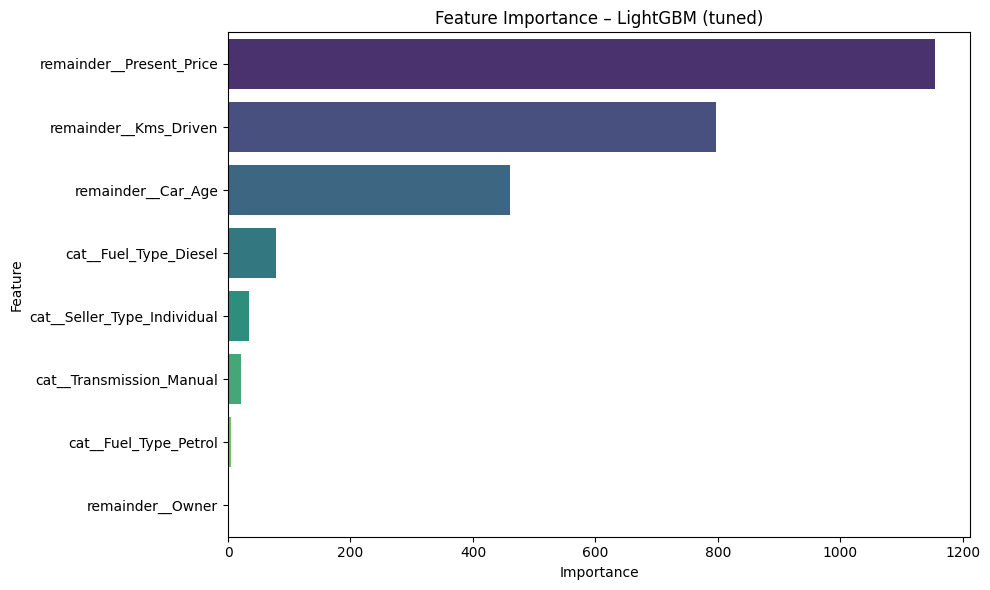

**Top driver of price:** `remainder__Present_Price`. Compare this against the EDA correlation heatmap -- if `Present_Price`/`Car_Age`-derived features dominate here too, it confirms the EDA's correlation-based findings; if a different feature (e.g. a `Fuel_Type` or `Transmission` dummy) ranks unexpectedly high, that's a non-linear/interaction effect the correlation heatmap alone couldn't reveal.

In [26]:
best_pipeline = pipelines[best_name]
best_estimator = best_pipeline.named_steps['model']

if hasattr(best_estimator, 'feature_importances_'):
    display(Markdown("### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Feature Importances (best model is tree-based)</span>"))

    feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()
    importances = best_estimator.feature_importances_

    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False).reset_index(drop=True)

    display(importance_df)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
    plt.title(f'Feature Importance – {best_name}')
    plt.tight_layout()
    plt.show()

    top_feature = importance_df.iloc[0]['Feature']
    display(Markdown(f"**Top driver of price:** `{top_feature}`. Compare this against the EDA correlation heatmap -- if `Present_Price`/`Car_Age`-derived features dominate here too, it confirms the EDA's correlation-based findings; if a different feature (e.g. a `Fuel_Type` or `Transmission` dummy) ranks unexpectedly high, that's a non-linear/interaction effect the correlation heatmap alone couldn't reveal."))
else:
    display(Markdown(f"### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Feature Importance</span>\n\n`{best_name}` is not tree-based, so it has no `feature_importances_` attribute. For a linear model like this, relative feature influence can instead be read from `best_estimator.coef_` (on the standardized features), which plays the same role as EDA's `Present_Price`/`Car_Age` correlations already suggested."))

# <h2 style= 'text-align:center; color:#27AE60; font-weight:bold;font-size:40px;  text-shadow:0 0 3px rgba(15,52,96,0.6);'>Save Best Model Pipeline</h2>

In [27]:
final_pipeline = pipelines[best_model['Model']]
display(Markdown(f"### <span style='color:#27AE60; font-weight:bold;font-size:20px;'>Using already-trained pipeline: {best_model['Model']}</span>"))

### <span style='color:#27AE60; font-weight:bold;font-size:20px;'>Using already-trained pipeline: LightGBM (tuned)</span>

In [28]:
final_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [29]:
model_path = r'D:\Education\AiQuest\DS,ML,DL\Projects\Car Price Prediction\models'

os.makedirs(model_path, exist_ok=True)

joblib.dump(
    final_pipeline,
    os.path.join(model_path, 'best_model.pkl')
)
display(Markdown("## <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Model saved successfully </span>"))

## <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Model saved successfully </span>